<a href="https://colab.research.google.com/github/egnorris/GeneticInverseDesign/blob/main/ColabDev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [149]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/GitHub/GeneticInverseDesign
import ProfileGeneration as pg
import Support as sp
import GeneticOperations as go
import numpy as np

In [92]:
BinaryPolygons[1]

'100011110101011011011110010111000101010101010100010101101100011000010101011101111100101000011011100010010100010110010101010000000000001100101100001011011000001011110000001101111000010010010111011010101111101011001101110101001011011110111001010100001111001110100101001011101010001010101000001011001110001101100110010010011010011011011010101101011011100011110101'

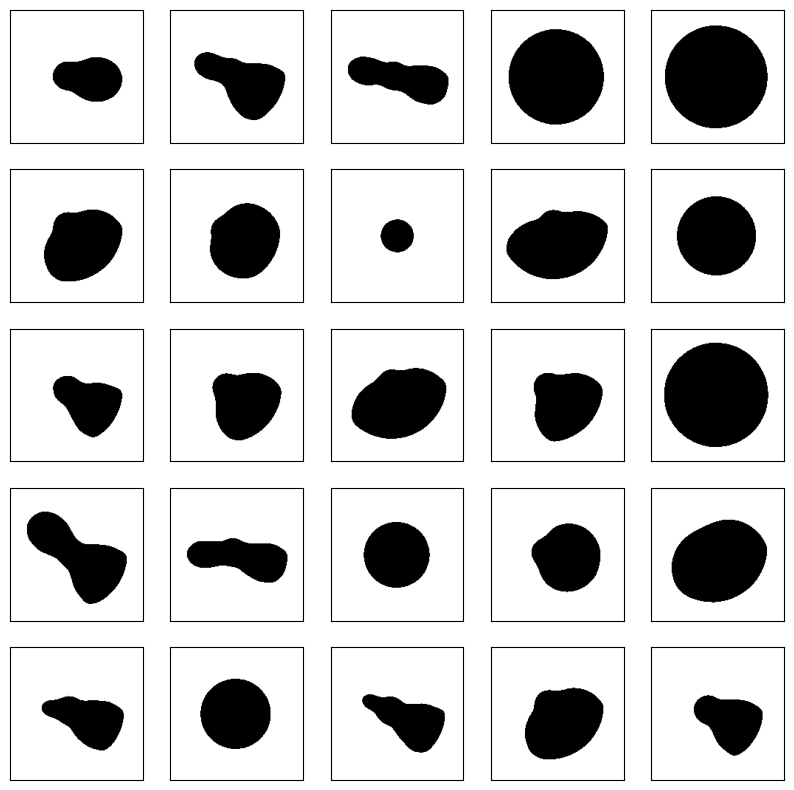

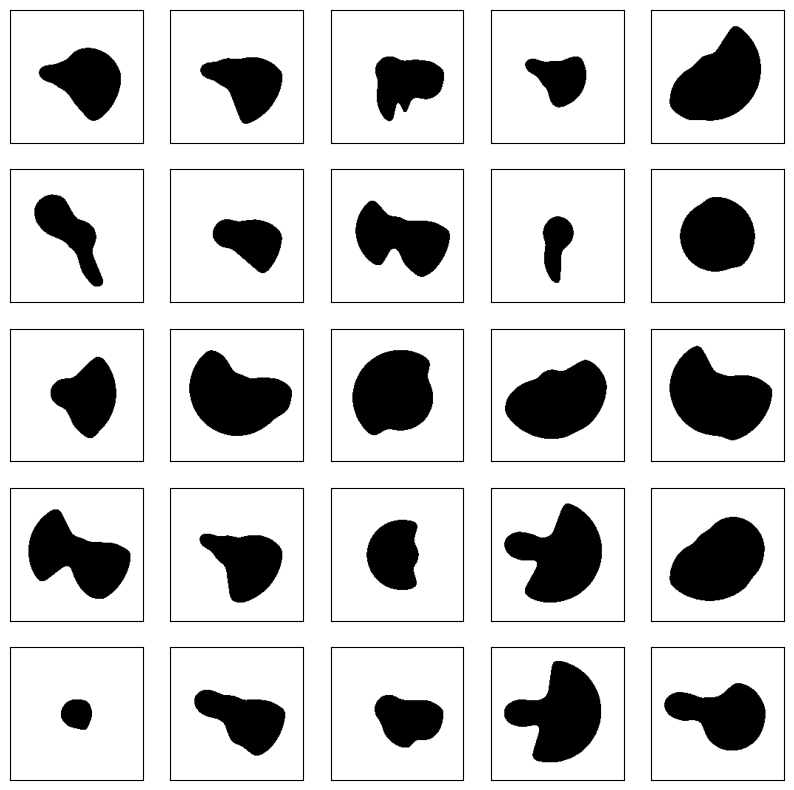

In [99]:
import GeneticOperations as go
import ProfileGeneration as pg
import matplotlib.pyplot as plt
import numpy as np

N = 25
Images = np.zeros((N, 180, 180))
BinaryPolygons = []


p = pg.ProfileGeneration(30)
for i in range(N):
  x = np.random.rand()
  if x < 0.25:
    p.triangleGenerator()
  if x > 0.25 and x < 0.5:
    p.rectangleGenerator()
  if x > 0.5 and x < 0.75:
    p.circleGenerator()
  else:
    p.fourierGenerator(np.random.randint(2,4))

  p.arrayConversion()
  p.encodePolygon()
  Images[i, :, :] = p.smoothedImage
  BinaryPolygons.append(p.binaryPolygon)


ChildImages = np.zeros((N, 180, 180))
ChildBinaryPolygons = np.zeros(N)

for i in range(N):
  p0 = BinaryPolygons[np.random.randint(N)]
  p1 = BinaryPolygons[np.random.randint(N)]
  g = go.GeneticOperations(p0, p1)
  g.crossover()
  g.mutate()
  p.binaryPolygon = g.c0
  p.decodePolygon()
  p.r = p.decodedPolygon
  p.arrayConversion()
  ChildImages[i, :, :] = p.smoothedImage
  ChildBinaryPolygons[i] = g.c0

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(Images[i, :, :], cmap=plt.cm.binary)
plt.show()
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(ChildImages[i, :, :], cmap=plt.cm.binary)
plt.show()